# Random Forests

## Importing Data

In [24]:
# Loading in data 
import pandas as pd 

data = pd.read_csv("clean_data_eda.csv")

In [ ]:
# Random forests packages
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, roc_curve
from sklearn.ensemble import RandomForestClassifier

## Getting Features and Splitting Data

In [26]:
# Converting categorical values into numerical ones
label_encoder = LabelEncoder()
data['Month'] = label_encoder.fit_transform(data['Month'])
data['VisitorType'] = label_encoder.fit_transform(data['VisitorType'])
data['Weekend'] = data['Weekend'].astype(int)

# Extracting Features
X = data.drop(columns=['Revenue'])
y = data["Revenue"]

In [27]:
# Splitting data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Fitting Base Model

In [ ]:
# Fitting Base Model (100 trees)
classifier = RandomForestClassifier(random_state=42)
classifier.fit(X_train, y_train)

# Predictions
predict = classifier.predict(X_test)
proba = classifier.predict_proba(X_test)[:, 1]

In [ ]:
# Assessing Performance 
roc = roc_auc_score(y_test, proba)
prec = average_precision_score(y_test, predict)
f1 = classification_report(y_test, predict, target_names=['No Purchase', 'Purchase'],
                        digits = 5, output_dict=True)['Purchase']['f1-score']

print(classification_report(y_test, predict, target_names=['No Purchase', 'Purchase'], digits = 5))
print(f"ROC-AUC Score: {roc:.5f}")
print(f"PR-AUC Score: {prec:.5f}")

              precision    recall  f1-score   support

 No Purchase    0.92877   0.96260   0.94539      2059
    Purchase    0.74919   0.60209   0.66763       382

    accuracy                        0.90619      2441
   macro avg    0.83898   0.78235   0.80651      2441
weighted avg    0.90067   0.90619   0.90192      2441

ROC-AUC Score: 0.92346
PR-AUC Score: 0.51335


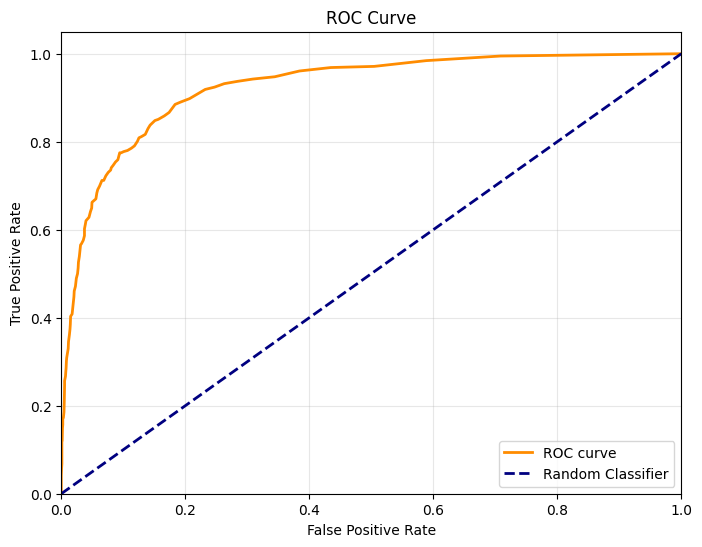

In [62]:
# ROC Curve Plot
fpr, tpr, thresholds = roc_curve(y_test, proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

The ROC Score is 0.923, which means that the base random forests model is performing very well! The F1 score is 0.66763, which is fine. The precision score on the other hand is only 0.513. Despite how well the base model is performing, we will experiment with different parameter values to see if we can tune the model and achieve better scores.

# Parameter Tuning and Experimenting

## Fitting Models w/ Varying # of Branches

In [ ]:
def branches(tree_num):
    # Fitting Model; n_jobs = -1 allows you to use all processors to fit the model so that it's faster
    classifier = RandomForestClassifier(n_estimators = tree_num, random_state=42, n_jobs= -1)
    classifier.fit(X_train, y_train)

    # Predictions
    predict = classifier.predict(X_test)
    proba = classifier.predict_proba(X_test)[:, 1]

    # Assessing performance 
    report = classification_report(y_test, predict, target_names=['No Purchase', 'Purchase'],
                                   digits = 5, output_dict= True)
    roc = roc_auc_score(y_test, proba)
    prec = average_precision_score(y_test, predict)
    
    return report, roc, prec

In [32]:
# Testing out different branch #s
branch = [100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600]
reports = []
rocs = []
precs = []

for i in branch:
    reports.append(branches(i)[0]['Purchase']['f1-score'])
    rocs.append(branches(i)[1])
    precs.append(branches(i)[2])

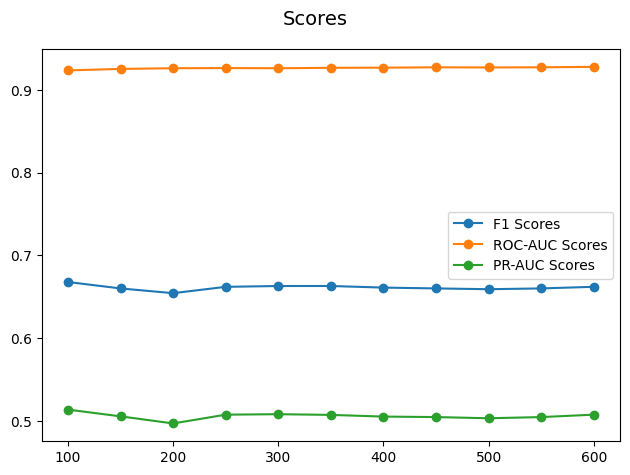

In [33]:
assess = pd.DataFrame({"F1 Scores": reports, "ROC-AUC Scores": rocs, "PR-AUC Scores": precs}, index = branch)

# Plots
assess.plot(marker = 'o')
plt.suptitle("Scores", fontsize=14)
plt.tight_layout()
plt.show()

In [34]:
# Getting max scores
rocMax = max(assess['ROC-AUC Scores'])
prMax = max(assess['PR-AUC Scores'])
f1Max = max(assess['F1 Scores'])

print(f'Best ROC-AUC Score: {rocMax:.5f}')
print(f'Best PR-AUC Score: {prMax:.5f}')
print(f'Best F1 Score: {f1Max:.5f}')

print(assess[['F1 Scores', 'ROC-AUC Scores', 'PR-AUC Scores']])

Best ROC-AUC Score: 0.92781
Best PR-AUC Score: 0.51335
Best F1 Score: 0.66763
     F1 Scores  ROC-AUC Scores  PR-AUC Scores
100   0.667634        0.923463       0.513350
150   0.659854        0.925304       0.505185
200   0.654124        0.926101       0.496616
250   0.661808        0.926328       0.507224
300   0.662791        0.926101       0.507807
350   0.662808        0.926612       0.506951
400   0.660870        0.926798       0.504919
450   0.659884        0.927221       0.504324
500   0.658926        0.927038       0.502888
550   0.659884        0.927242       0.504324
600   0.661808        0.927805       0.507224


As we can see here, the best F1 score is 0.6676 (100 branches), the best ROC-AUC score is 0.9278 (600 branches), the best PR-AUC score is 0.5133 (100 branches). This means that the best model is the one with 100 branches, but we will see if that still holds up once we balance our data. 

## Fitting Models with Balanced Weights

In [ ]:
def balanced_branches(tree_num):
    # Fitting Model
    classifier = RandomForestClassifier(n_estimators = tree_num, random_state=42, class_weight="balanced", n_jobs= -1)
    classifier.fit(X_train, y_train)

    # Predictions
    predict = classifier.predict(X_test)
    proba = classifier.predict_proba(X_test)[:, 1]

    # Assessing performance 
    report = classification_report(y_test, predict, target_names=['No Purchase', 'Purchase'], 
                                   digits = 5, output_dict= True)
    roc = roc_auc_score(y_test, proba)
    prec = average_precision_score(y_test, predict)
    
    return report, roc, prec

In [36]:
# Testing out different branch #s
reports2 = []
rocs2 = []
precs2 = []

for i in branch:
    reports2.append(balanced_branches(i)[0]['Purchase']['f1-score'])
    rocs2.append(balanced_branches(i)[1])
    precs2.append(balanced_branches(i)[2])

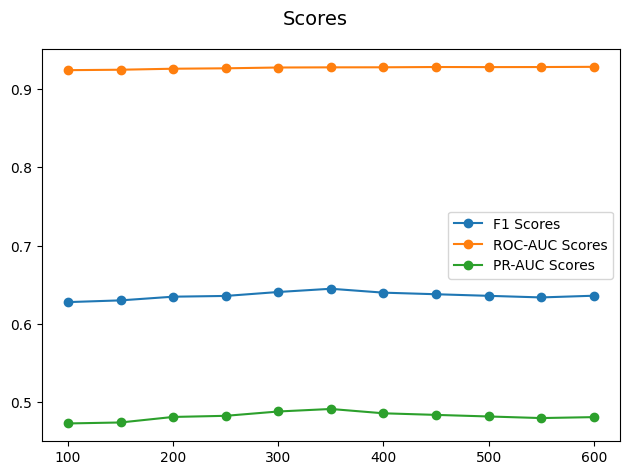

In [37]:
assess2 = pd.DataFrame({"F1 Scores":reports2, "ROC-AUC Scores":rocs2, "PR-AUC Scores":precs2}, index = branch)

# Plots
assess2.plot(marker = 'o')
plt.suptitle("Scores", fontsize=14)
plt.tight_layout()
plt.show()

In [38]:
# Getting max scores
rocMax2 = max(assess2['ROC-AUC Scores'])
prMax2 = max(assess2['PR-AUC Scores'])
f1Max2 = max(assess2['F1 Scores'])

print(f'Best ROC-AUC Score: {rocMax2:.5f}')
print(f'Best PR-AUC Score: {prMax2:.5f}')
print(f'Best F1 Score: {f1Max2:.5f}')

print(assess2[['F1 Scores', 'ROC-AUC Scores', 'PR-AUC Scores']])

Best ROC-AUC Score: 0.92852
Best PR-AUC Score: 0.49120
Best F1 Score: 0.64487
     F1 Scores  ROC-AUC Scores  PR-AUC Scores
100   0.627803        0.924260       0.472710
150   0.630015        0.924815       0.473954
200   0.634731        0.926103       0.481023
250   0.635682        0.926627       0.482466
300   0.640719        0.927649       0.488002
350   0.644874        0.927857       0.491202
400   0.639881        0.927931       0.485683
450   0.637854        0.928279       0.483651
500   0.635821        0.928171       0.481619
550   0.633782        0.928250       0.479589
600   0.635958        0.928518       0.480800


Here, we can see some improvement in the overall scores after balancing our data. Although 600 branches provide us with the best scores in ROC-AUC, we will settle with 350 branches for the sake of performance and due to the trivial improvement in the overall score. 

## Fitting Models with Balanced Weights and Smoothing

In [ ]:
def balanced_leaves(sample_leaf):
    # Fitting Model
    classifier = RandomForestClassifier(n_estimators = 350, random_state=42, class_weight="balanced", min_samples_leaf = sample_leaf, n_jobs= -1)
    classifier.fit(X_train, y_train)

    # Predictions
    predict = classifier.predict(X_test)
    proba = classifier.predict_proba(X_test)[:, 1]

    # Assessing performance 
    report = classification_report(y_test, predict, target_names=['No Purchase', 'Purchase'], 
                                   digits = 5, output_dict=True)
    roc = roc_auc_score(y_test, proba)
    prec = average_precision_score(y_test, predict)
    
    return report, roc, prec

In [40]:
# Testing out different leaf #s
leaves = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
reports3 = []
rocs3 = []
precs3 = []

for i in leaves:
    reports3.append(balanced_leaves(i)[0]['Purchase']['f1-score'])
    rocs3.append(balanced_leaves(i)[1])
    precs3.append(balanced_leaves(i)[2])

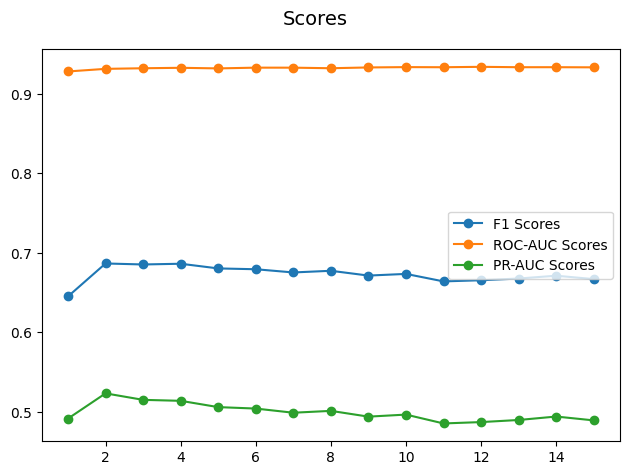

In [41]:
assess3 = pd.DataFrame({"F1 Scores":reports3, "ROC-AUC Scores":rocs3, "PR-AUC Scores":precs3}, index = leaves)

# Plots
assess3.plot(marker = 'o')
plt.suptitle("Scores", fontsize=14)
plt.tight_layout()
plt.show()

In [42]:
# Getting max scores
rocMax3 = max(assess['ROC-AUC Scores'])
prMax3 = max(assess['PR-AUC Scores'])
f1Max3 = max(assess['F1 Scores'])

print(f'Best ROC-AUC Score: {rocMax3:.5f}')
print(f'Best PR-AUC Score: {prMax3:.5f}')
print(f'Best F1 Score: {f1Max3:.5f}')

print(assess3[['F1 Scores', 'ROC-AUC Scores', 'PR-AUC Scores']])

Best ROC-AUC Score: 0.92781
Best PR-AUC Score: 0.51335
Best F1 Score: 0.66763
    F1 Scores  ROC-AUC Scores  PR-AUC Scores
1    0.644874        0.927857       0.491202
2    0.686327        0.931131       0.522937
3    0.685069        0.931893       0.514779
4    0.685990        0.932458       0.513559
5    0.680095        0.931699       0.505641
6    0.679070        0.932645       0.503825
7    0.675029        0.932626       0.498588
8    0.677130        0.931908       0.500918
9    0.671096        0.932905       0.493665
10   0.673203        0.933322       0.496231
11   0.663784        0.933167       0.485099
12   0.665227        0.933679       0.486814
13   0.667382        0.933192       0.489443
14   0.670927        0.933210       0.493788
15   0.666667        0.933042       0.488949


When we adjust the minimum number of leaves required to form a node, we essentially perform smoothing in the model. This prevents the model from overfitting the training data.

As we can see, adjustng the amount of minimum number of leaves required to form a node improved the performance of the model. However, the improvement becomes minimal as the number of leaves is >4. For now, we will settle with a minimum of 2 leaves per node.

## Fitting Models with Extra Trees

Extra Trees is essentially the same as random forests, except it adds more randomness by randomly selecting a threshold for each node. Compared to random forests, it might help reduce variance, but we will find out soon.

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier

classifier2 = ExtraTreesClassifier(n_estimators= 350, min_samples_leaf= 2, 
                                   class_weight='balanced', random_state=42, n_jobs = 1)

classifier2.fit(X_train, y_train)

predict2 = classifier2.predict(X_test)
proba2 = classifier2.predict_proba(X_test)[:, 1]

# Assessing Performance
roc2 = roc_auc_score(y_test, proba2)
prec2 = average_precision_score(y_test, predict2)
f12 = classification_report(y_test, predict2, target_names=['No Purchase', 'Purchase'], output_dict=True)['Purchase']['f1-score']

print(f'ROC-AUC: {roc2:.4f}')
print(f'PR-AUC: {prec2:.4f}')
print(classification_report(y_test, predict2, target_names=['No Purchase', 'Purchase']))

ROC-AUC: 0.9212
PR-AUC: 0.4874
              precision    recall  f1-score   support

 No Purchase       0.94      0.93      0.93      2059
    Purchase       0.64      0.69      0.66       382

    accuracy                           0.89      2441
   macro avg       0.79      0.81      0.80      2441
weighted avg       0.89      0.89      0.89      2441



Compared to the other models that we have fitted so far, the extra trees model unfortunately doesn't perform as well.

# Final Model

In [51]:
# Arranging data
index = ['RF Base', 'RF Tuned Branches', 'RF Balanced', 'RF Smooth and Balanced', 'Extra Trees']
f1s = [f1, reports[5], reports2[5], reports3[1], f12]
rocss = [roc, rocs[5], rocs2[5], rocs3[1], roc2]
aps = [prec, precs[5], precs2[5], precs3[5], prec2]

summary = pd.DataFrame({'F1 Scores':f1s, 'ROC-AUC Scores': rocss, 'PR-AUC Scores': aps}, index=index)
print(summary)

                        F1 Scores  ROC-AUC Scores  PR-AUC Scores
RF Base                  0.667634        0.923463       0.513350
RF Tuned Branches        0.662808        0.926612       0.506951
RF Balanced              0.644874        0.927857       0.491202
RF Smooth and Balanced   0.686327        0.931131       0.503825
Extra Trees              0.661616        0.921223       0.487444


As we can see, the **smooth and balanced random forests model** has the highest F1 and ROC-AUC scores out of every other model in the table. Thus, out final model will be the RF Smooth and Balanced Model, where the number of branches are set to 350, and the minimum number of leaves required to form a node is 2. 

The final scores are 0.931131 (ROC-AUC), 0.503825 (PR-AUC), and 0.686327 (F1).

## Extracting Top Features

In [ ]:
# Fitting Final Model
classifier3  = RandomForestClassifier(n_estimators = 350, random_state=42, 
                                      class_weight="balanced", min_samples_leaf = 2, n_jobs= -1)
classifier3.fit(X_train, y_train)

# Predictions
predict3 = classifier3.predict(X_test)
proba3 = classifier3.predict_proba(X_test)[:, 1]

In [ ]:
# Getting top 10 features
top = pd.Series(classifier3.feature_importances_, index=X.columns)
top10 = top.sort_values(ascending=False).head(10)
print('Features          Average Decrease in Impurity')
print('----------------------------------------------------')
print(top10)

Features          Average Decrease in Impurity
----------------------------------------------------
PageValues                 0.423476
ExitRates                  0.093272
ProductRelated_Duration    0.089233
ProductRelated             0.066062
Month                      0.064528
BounceRates                0.051550
Administrative_Duration    0.047806
Administrative             0.036623
TrafficType                0.024824
Region                     0.023473
dtype: float64
